### import necessary libraries

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,auc,roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

### import dataset

In [3]:
claiments_data = pd.read_csv(filepath_or_buffer="claiments.csv")

In [4]:
claiments_data.shape

(1340, 7)

In [5]:
claiments_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


### data understanding

In [6]:
claiments_data.shape

(1340, 7)

In [7]:
claiments_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [8]:
claiments_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

### data cleaning

In [9]:
claiments_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [10]:
claiments_data.dropna()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [11]:
claiments_data = claiments_data.dropna()

In [12]:
claiments_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [13]:
claiments_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [14]:
claiments_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

### splitting the input and output features

In [15]:
X = claiments_data.drop(labels=["ATTORNEY","CASENUM"],axis=1)

In [16]:
y = claiments_data["ATTORNEY"]

In [17]:
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [18]:
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

### MODEL building

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,shuffle=True,random_state=101)

In [21]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
1306,1.0,1.0,0.0,38.0,0.005
58,1.0,1.0,0.0,44.0,0.139
419,0.0,0.0,0.0,50.0,3.719
1172,0.0,1.0,0.0,13.0,0.746
189,1.0,0.0,0.0,65.0,0.373
...,...,...,...,...,...
702,1.0,1.0,0.0,40.0,3.570
1188,1.0,1.0,0.0,44.0,13.000
92,1.0,1.0,0.0,8.0,0.860
729,0.0,1.0,0.0,11.0,0.500


In [22]:
logistic_model = LogisticRegression()

### model training

In [23]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### model testing

##### train data

In [24]:
y_pred_train = logistic_model.predict(X_train)
y_pred_train

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,

##### test data

In [25]:
y_pred_test = logistic_model.predict(X_test)
y_pred_test

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1])

### model evaluation

##### training accuracy

In [26]:
accuracy_score(y_train,y_pred_train)

0.70662100456621

### model Deployment

In [27]:
#from pickle import dump

In [28]:
#dump(logistic_model,open("claiments.pkl","wb"))

### the end!!!

## SELF EVALUATION

#### EVALUATION MATRICS

In [29]:
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [30]:
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=101,shuffle=True)

In [32]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
1306,1.0,1.0,0.0,38.0,0.005
58,1.0,1.0,0.0,44.0,0.139
419,0.0,0.0,0.0,50.0,3.719
1172,0.0,1.0,0.0,13.0,0.746
189,1.0,0.0,0.0,65.0,0.373
...,...,...,...,...,...
702,1.0,1.0,0.0,40.0,3.570
1188,1.0,1.0,0.0,44.0,13.000
92,1.0,1.0,0.0,8.0,0.860
729,0.0,1.0,0.0,11.0,0.500


In [33]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
759,0.0,0.0,0.0,30.0,9.909
887,0.0,1.0,0.0,77.0,0.050
1266,1.0,1.0,0.0,37.0,0.193
1083,1.0,1.0,0.0,35.0,1.713
480,0.0,1.0,0.0,47.0,0.090
...,...,...,...,...,...
215,1.0,1.0,0.0,77.0,0.944
257,0.0,1.0,0.0,15.0,3.070
907,0.0,1.0,0.0,39.0,8.815
645,0.0,1.0,0.0,17.0,5.118


In [34]:
y_train

1306    1
58      1
419     0
1172    1
189     1
       ..
702     0
1188    0
92      1
729     1
1060    0
Name: ATTORNEY, Length: 876, dtype: int64

In [35]:
y_test

759     0
887     1
1266    1
1083    1
480     1
       ..
215     1
257     0
907     0
645     0
365     1
Name: ATTORNEY, Length: 220, dtype: int64

In [36]:
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

In [37]:
y_pred = logistic_model.predict(X_train)

In [38]:
accuracy_score(y_train,y_pred)

0.70662100456621

In [54]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,precision_score,recall_score,roc_curve

#### train data evaluation metrics

In [47]:
recall_score(y_train,y_pred_train)

0.7564402810304449

In [48]:
precision_score(y_train,y_pred_train)

0.6785714285714286

In [40]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.66      0.70       449
           1       0.68      0.76      0.72       427

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.71      0.71      0.71       876



In [49]:
print(confusion_matrix(y_train,y_pred_train))

[[296 153]
 [104 323]]


In [50]:
print(accuracy_score(y_train,y_pred_train))

0.70662100456621


#### test data evaluation metrics

In [43]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.81      0.60      0.69       129
           1       0.59      0.80      0.68        91

    accuracy                           0.69       220
   macro avg       0.70      0.70      0.69       220
weighted avg       0.72      0.69      0.69       220



In [44]:
print(confusion_matrix(y_test,y_pred_test))

[[78 51]
 [18 73]]


In [51]:
print(accuracy_score(y_test,y_pred_test))

0.6863636363636364


In [53]:
precision_score(y_train,y_pred_train)

0.6785714285714286

In [52]:
recall_score(y_train,y_pred_train)

0.7564402810304449

### ROC CURVE - RECEIVER OPERATING CHARACTERISTICS

#### AUC - AREA UNDER THIS CURVE

In [64]:
# TRAIN data

0.7078415213615477


Text(0, 0.5, 'True Positive Rate')

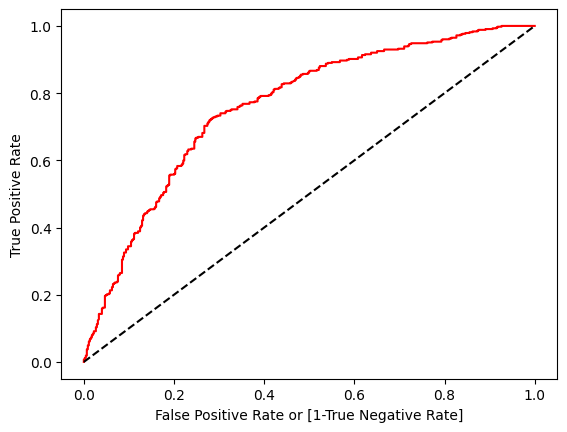

In [60]:
fpr, tpr, thresholds = roc_curve(y_train,logistic_model.predict_proba(X_train)[:,-1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

plt.plot(fpr,tpr,color="red",label = 'logit model (area = %0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate or [1-True Negative Rate]")
plt.ylabel("True Positive Rate")

In [63]:
# TEST data

0.7034244824942499


Text(0, 0.5, 'True Positive Rate')

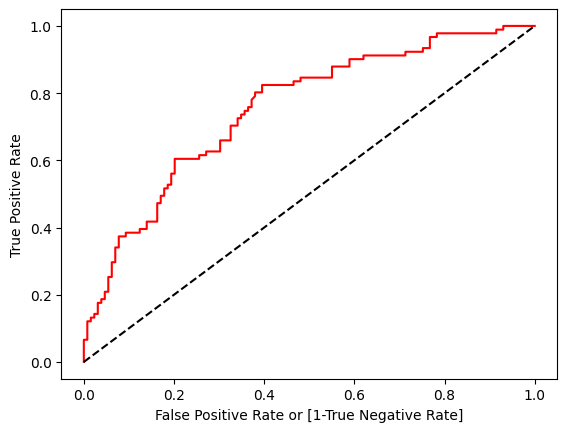

In [62]:
fpr, tpr, thresholds = roc_curve(y_test,logistic_model.predict_proba(X_test)[:,-1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

plt.plot(fpr,tpr,color="red",label = 'logit model (area = %0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate or [1-True Negative Rate]")
plt.ylabel("True Positive Rate")